In [1]:
library(ggplot2)
library(dplyr)
library(stringr)
library(tidyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
celltype_colors <- c(
  NK = "#6A0DAD",          
  T = "#9B59B6",           
  Endothelial = "#CF1B14", 
  Myeloid = "#E8773B",     
  B = "#E995E7",           
  Cholangiocyte = "#E1AD01",
  HSC = "#4682B4",         
  Mast = "#FD7BB8",        
  Schwann = "#81CDC6",     
  Hepatocytes = "#4DAF4A"  
)

cellsubtype_colors <- c(
  NK = "#6A0DAD",                         
  T = "#9B59B6",                          
  Sinusoidal.Endothelial = "#CF1B14",     
  Lymphatic.Endothelial = "#FFCBC2",      
  Central.Vein.Endothelial = "#F27C78",   
  Vascular.Endothelial = "#8E0B0B",       
  Kupffer = "#B04202",                    
  Macrophage = "#F5AD75",                 
  Lipid.Associated.Macrophage = "#FF7105",
  B = "#9E239A",                          
  Plasma = "#E995E7",                     
  Cholangiocyte = "#E1AD01",              
  Quescent.HSC = "#4682B4",               
  Activated.HSC = "#1E90FF",              
  Mesenchymal = "#004F9E",                
  Mast = "#FD7BB8",                       
  Schwann = "#81CDC6",                    
  Hepatocytes.Zone1 = "#006D2C",          
  Hepatocytes.Zone2 = "#4DAF4A",          
  Hepatocytes.Zone3 = "#9ED69F",          
  Hepatocytes.Senescent = "#AED96A",      
  Hepatocytes.Stress = "#526E12"          
)

In [3]:
meta_df <- read.table('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/01_DESEQ_RNA/RNA.meta.tsv', sep='\t', header=T) 
meta_df

donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,⋯,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<chr>,<chr>,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>
HL150001,85,47,746,8760,308,4,726,167,8,⋯,0,0,0,0,1,M,47,27.10,-0.638584666,-0.01553551
HL150009,19,34,459,2317,329,0,227,23,6,⋯,0,0,0,0,1,M,37,29.40,-0.334686949,-0.75778750
HL150013,93,31,553,541,308,31,459,100,1,⋯,1,1,1-2 Mild/moderate,Spotty,3,M,45,35.00,0.405237926,-0.16398591
HL150015,59,59,410,4421,312,1,199,63,7,⋯,0,0,1,0,3,M,59,29.10,-0.374325782,0.87516689
HL160017,54,68,662,6986,199,0,683,39,2,⋯,1,0,2,0,2,M,31,24.00,-1.048185936,-1.20313870
HL160022,9,187,349,1097,334,0,468,22,8,⋯,1,1,1,0,5,F,45,29.80,-0.281835172,-0.16398591
HL160026,15,29,721,6012,452,0,66,31,0,⋯,0,0,0,Spotty,0,F,25,26.00,-0.783927052,-1.64848990
HL160029,5,8,299,1104,189,0,136,28,5,⋯,0,0,0,0,0,F,47,30.86,-0.141777964,-0.01553551
HL160030,27,72,728,3785,314,3,213,51,6,⋯,0,0,0,0,2,M,29,30.20,-0.228983396,-1.35158910


In [4]:
colnames(meta_df)

[1] "donor_demux"          "B"                    "Cholangiocyte"       
 [4] "Endothelial"          "Hepatocytes"          "HSC"                 
 [7] "Mast"                 "Myeloid"              "NK"                  
[10] "Schwann"              "T"                    "batch"               
[13] "disease_status"       "condition"            "Steatosis.grade"     
[16] "Fibrosis.stage"       "Fat.distribution"     "Lobular.inflammation"
[19] "Ballooning"           "Portal.inflammation"  "Hepatocyte.necrosis" 
[22] "MASH.CRN.score..X.8"  "Gender"               "Age"                 
[25] "BMI"                  "BMI.scaled"           "Age.scaled"

In [5]:
meta_df$condition %>% table()

.
Control    MASH    MASL  MetALD 
     26      23      25      12 

`geom_smooth()` using formula = 'y ~ x'


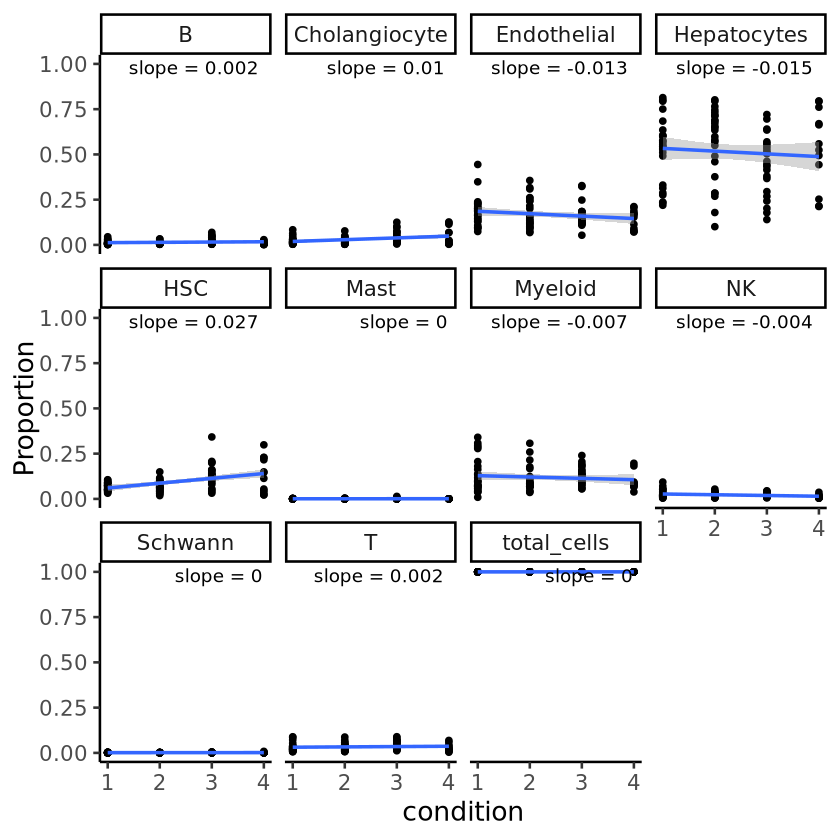

In [6]:
slopes <- meta_df %>%
    mutate(total_cells=B+Cholangiocyte+Endothelial+Hepatocytes+
                           HSC+Mast+Myeloid+NK+Schwann+T) %>%
    select(B, Cholangiocyte, Endothelial, Hepatocytes,
                           HSC, Mast, Myeloid, NK, Schwann, T, total_cells, donor_demux, condition) %>%
    mutate(across(c(-donor_demux, -condition), ~ . / total_cells)) %>%
    pivot_longer(c(B, Cholangiocyte, Endothelial, Hepatocytes,
                           HSC, Mast, Myeloid, NK, Schwann, T, total_cells), 
                 names_to='Cell_Type',values_to='Proportion') %>%
    mutate(condition=as.numeric(factor(condition, levels=c('Control','MASL','MASH','MetALD')))) %>%
  group_by(Cell_Type) %>%
  do({
    fit <- lm(Proportion ~ condition, data = .)
    data.frame(slope = coef(fit)[2])
  })

meta_df %>%
    mutate(total_cells=B+Cholangiocyte+Endothelial+Hepatocytes+
                           HSC+Mast+Myeloid+NK+Schwann+T) %>%
    select(B, Cholangiocyte, Endothelial, Hepatocytes,
                           HSC, Mast, Myeloid, NK, Schwann, T, total_cells, donor_demux, condition) %>%
    mutate(across(c(-donor_demux, -condition), ~ . / total_cells)) %>%
    pivot_longer(c(B, Cholangiocyte, Endothelial, Hepatocytes,
                           HSC, Mast, Myeloid, NK, Schwann, T, total_cells), 
                 names_to='Cell_Type',values_to='Proportion') %>%
    mutate(condition=as.numeric(factor(condition, levels=c('Control','MASL','MASH','MetALD')))) %>%
    ggplot(aes(y=Proportion, x=condition)) +
        facet_wrap(. ~ Cell_Type) +
        geom_point() +
        theme_classic(base_size=16) +
        geom_smooth(method = 'lm') +
        geom_text(
            data = slopes,
            aes(x = Inf, y = Inf, label = paste0("slope = ", round(slope, 3))),
            hjust = 1.1, vjust = 1.5,
            inherit.aes = FALSE
        )

In [9]:
meta_df.sub <- read.table('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/cellsubtypes_donor_cell_nums.tsv', sep='\t', header=T)  %>%
    left_join(select(meta_df, condition, Fibrosis.stage, donor=donor_demux))
meta_df.sub

Joining with `by = join_by(donor)`


donor,Activated.HSC,B,Central.Vein.Endothelial,Cholangiocyte,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3,⋯,Mesenchymal,NK,Plasma,Quescent.HSC,Schwann,Sinusoidal.Endothelial,T,Vascular.Endothelial,condition,Fibrosis.stage
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<int>
HL150001,124,29,28,47,392,1,541,5047,2779,⋯,45,167,56,139,8,694,79,22,MASL,0
HL150009,107,9,15,34,25,0,124,1655,513,⋯,52,23,10,170,6,406,36,32,MASL,0
HL150013,122,31,33,31,70,0,48,304,119,⋯,27,100,62,159,1,493,114,24,MASH,2
HL150015,81,3,15,59,124,4,345,3164,784,⋯,29,63,56,202,7,379,37,14,MASL,1
HL160017,45,12,23,68,263,2002,242,858,3621,⋯,15,39,42,139,2,604,129,26,MetALD,2
HL160022,144,3,23,187,541,1,15,335,205,⋯,27,22,6,163,8,291,56,31,MASH,2
HL160026,86,1,27,29,767,0,522,3609,1114,⋯,19,31,14,347,0,654,61,39,Control,0
HL160029,43,2,3,8,36,0,301,416,351,⋯,4,28,3,142,5,288,61,8,Control,0
HL160030,176,8,24,72,35,0,471,1778,1501,⋯,32,51,19,106,6,671,102,31,MASL,0


In [10]:
colnames(meta_df.sub)

[1] "donor"                       "Activated.HSC"              
 [3] "B"                           "Central.Vein.Endothelial"   
 [5] "Cholangiocyte"               "Hepatocytes.Senescent"      
 [7] "Hepatocytes.Stress"          "Hepatocytes.Zone1"          
 [9] "Hepatocytes.Zone2"           "Hepatocytes.Zone3"          
[11] "Kupffer"                     "Lipid.Associated.Macrophage"
[13] "Lymphatic.Endothelial"       "Macrophage"                 
[15] "Mast"                        "Mesenchymal"                
[17] "NK"                          "Plasma"                     
[19] "Quescent.HSC"                "Schwann"                    
[21] "Sinusoidal.Endothelial"      "T"                          
[23] "Vascular.Endothelial"        "condition"                  
[25] "Fibrosis.stage"

In [12]:
lineage <- data.frame(Cell_Type=c('Activated.HSC', 'B', 'Central.Vein.Endothelial', 'Cholangiocyte', 'Hepatocytes.Senescent', 
                      'Hepatocytes.Stress', 'Hepatocytes.Zone1', 'Hepatocytes.Zone2', 'Hepatocytes.Zone3', 'Kupffer', 
                      'Lipid.Associated.Macrophage', 'Lymphatic.Endothelial', 'Macrophage', 'Mast', 'Mesenchymal', 
                      'NK', 'Plasma', 'Quescent.HSC', 'Schwann', 'Sinusoidal.Endothelial', 
                      'T', 'Vascular.Endothelial'),
                     Group=c('HSC','Other','Endothelial','Other','Hepatocytes',
                     'Hepatocytes','Hepatocytes','Hepatocytes','Hepatocytes','Myeloid',
                     'Myeloid','Endothelial','Myeloid','Other','HSC',
                     'Other','Other','HSC','Other','Endothelial',
                     'Other','Endothelial'))
lineage

Cell_Type,Group
<chr>,<chr>
Activated.HSC,HSC
B,Other
Central.Vein.Endothelial,Endothelial
Cholangiocyte,Other
Hepatocytes.Senescent,Hepatocytes
Hepatocytes.Stress,Hepatocytes
Hepatocytes.Zone1,Hepatocytes
Hepatocytes.Zone2,Hepatocytes
Hepatocytes.Zone3,Hepatocytes


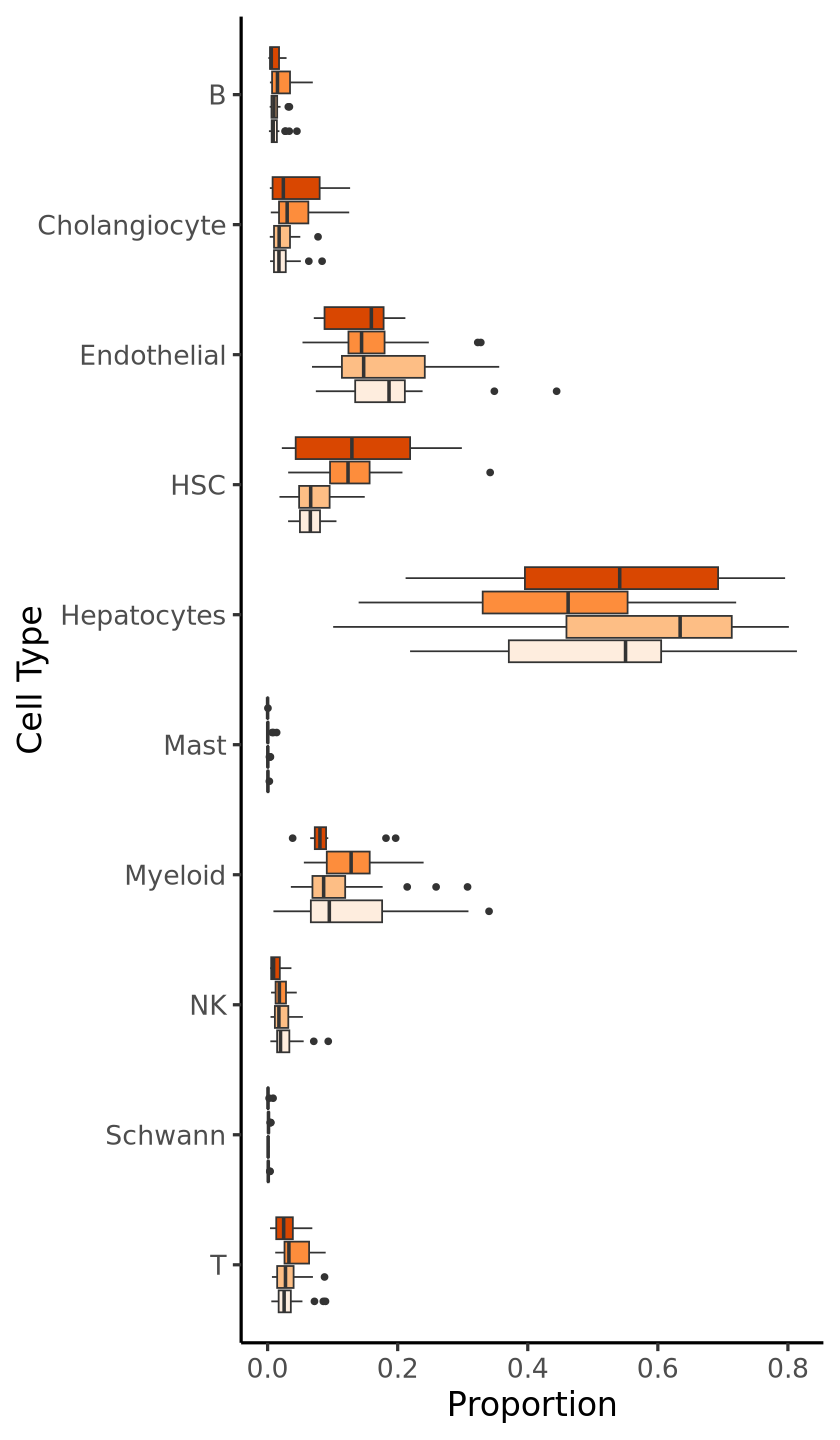

In [92]:
options(repr.plot.width=7, repr.plot.height=12)
cts.levels <- c('T', 'Schwann', 'NK', 'Myeloid', 'Mast', 'Hepatocytes', 'HSC', 'Endothelial', 'Cholangiocyte', 'B')
p1 <- meta_df %>%
    mutate(total_cells=B+Cholangiocyte+Endothelial+Hepatocytes+
                           HSC+Mast+Myeloid+NK+Schwann+T) %>%
    select(B, Cholangiocyte, Endothelial, Hepatocytes,
                           HSC, Mast, Myeloid, NK, Schwann, T, total_cells, donor_demux, condition) %>%
    mutate(across(c(-donor_demux, -condition), ~ . / total_cells)) %>%
    pivot_longer(c(B, Cholangiocyte, Endothelial, Hepatocytes,
                           HSC, Mast, Myeloid, NK, Schwann, T, total_cells), 
                 names_to='Cell_Type',values_to='Proportion') %>%
    mutate(condition=factor(condition, levels=c('Control','MASL','MASH','MetALD'))) %>%
    filter(Cell_Type != 'total_cells') %>%
    group_by(Cell_Type) %>%
    mutate(Cell_Type=factor(Cell_Type, levels=cts.levels)) %>%
    ggplot(aes(y=Cell_Type, x=Proportion, fill=condition)) +
        geom_boxplot() +
        theme_classic(base_size=20) +
        scale_fill_brewer(palette = 'Oranges', direction = 1) +
        labs(y='Cell Type', fill='Condition') +
        theme(legend.position='none')

p1

ggsave(plot = p1, filename = '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260511_WE_scCODA_Celltype_Condition_R_Proportions.pdf', width=7, height=12)

options(repr.plot.width=8, repr.plot.height=8)

Joining with `by = join_by(Cell_Type)`


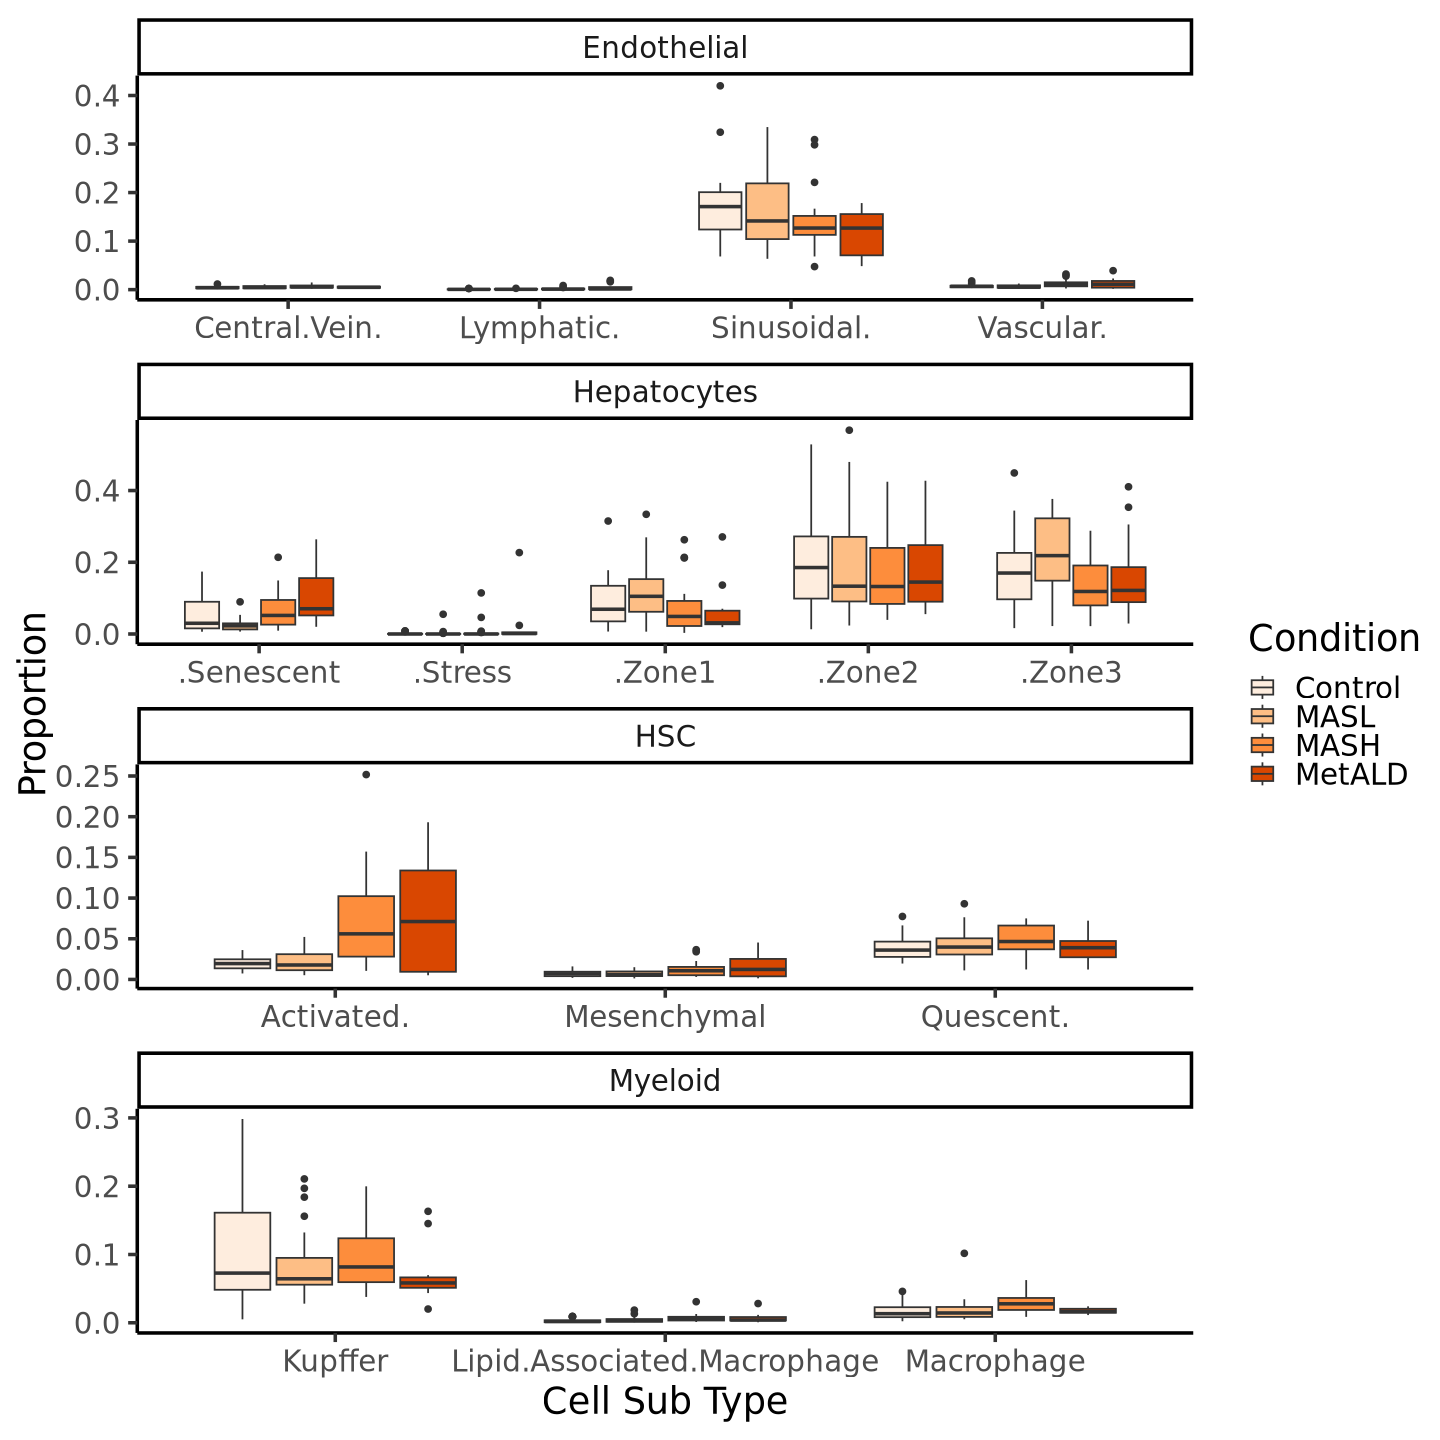

In [78]:
options(repr.plot.width=12, repr.plot.height=12)
p1 <- meta_df.sub %>%
    mutate(total_cells=Activated.HSC+B+Central.Vein.Endothelial+Cholangiocyte+Hepatocytes.Senescent+
           Hepatocytes.Stress+Hepatocytes.Zone1+Hepatocytes.Zone2+Hepatocytes.Zone3+Kupffer+
           Lipid.Associated.Macrophage+Lymphatic.Endothelial+Macrophage+Mast+Mesenchymal+
           NK+Plasma+Quescent.HSC+Schwann+Sinusoidal.Endothelial+T+Vascular.Endothelial) %>%
    select(Activated.HSC, B, Central.Vein.Endothelial, Cholangiocyte, Hepatocytes.Senescent, 
           Hepatocytes.Stress, Hepatocytes.Zone1, Hepatocytes.Zone2, Hepatocytes.Zone3, 
           Kupffer, Lipid.Associated.Macrophage, Lymphatic.Endothelial, Macrophage, Mast, 
           Mesenchymal, NK, Plasma, Quescent.HSC, Schwann, Sinusoidal.Endothelial, T, 
           Vascular.Endothelial, total_cells, donor, condition) %>%
    mutate(across(c(-donor, -condition), ~ . / total_cells)) %>%
    pivot_longer(c(Activated.HSC, B, Central.Vein.Endothelial, Cholangiocyte, Hepatocytes.Senescent, 
           Hepatocytes.Stress, Hepatocytes.Zone1, Hepatocytes.Zone2, Hepatocytes.Zone3, 
           Kupffer, Lipid.Associated.Macrophage, Lymphatic.Endothelial, Macrophage, Mast, 
           Mesenchymal, NK, Plasma, Quescent.HSC, Schwann, Sinusoidal.Endothelial, T, 
           Vascular.Endothelial, total_cells), 
                 names_to='Cell_Type',values_to='Proportion') %>%
    mutate(condition=factor(condition, levels=c('Control','MASL','MASH','MetALD'))) %>%
    filter(Cell_Type != 'total_cells') %>%
    group_by(Cell_Type) %>%
    left_join(lineage) %>%
    filter(Group != 'Other') %>%
    mutate(Cell_Type=str_remove(Cell_Type, Group)) %>%
    ggplot(aes(x=Cell_Type, y=Proportion, fill=condition)) +
        geom_boxplot() +
        theme_classic(base_size=22) +
        scale_fill_brewer(palette = 'Oranges', direction = 1) +
        labs(x='Cell Sub Type', fill='Condition') +
        facet_wrap(. ~ Group, scales='free', ncol=1)

p1

ggsave(plot = p1, filename = '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260511_WE_scCODA_Subtype_Condition_R_Proportions.pdf', width=12, height=12)

options(repr.plot.width=8, repr.plot.height=8)

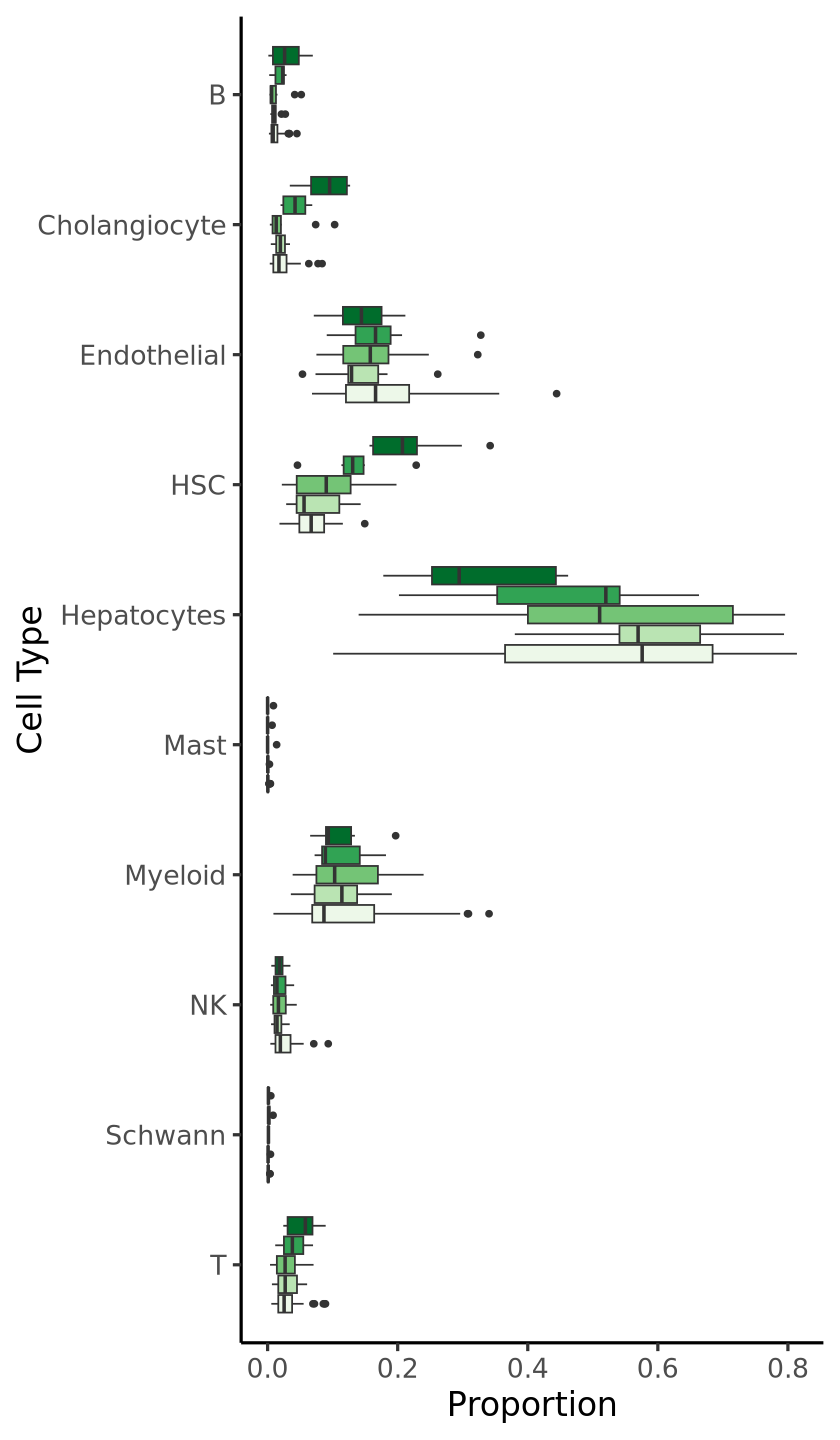

In [66]:
options(repr.plot.width=7, repr.plot.height=12)
p1 <- meta_df %>%
    mutate(total_cells=B+Cholangiocyte+Endothelial+Hepatocytes+
                           HSC+Mast+Myeloid+NK+Schwann+T) %>%
    select(B, Cholangiocyte, Endothelial, Hepatocytes,
                           HSC, Mast, Myeloid, NK, Schwann, T, total_cells, donor_demux, Fibrosis.stage) %>%
    mutate(across(c(-donor_demux, -Fibrosis.stage), ~ . / total_cells)) %>%
    pivot_longer(c(B, Cholangiocyte, Endothelial, Hepatocytes,
                           HSC, Mast, Myeloid, NK, Schwann, T, total_cells), 
                 names_to='Cell_Type',values_to='Proportion') %>%
    filter(Cell_Type != 'total_cells') %>%
    mutate(Fibrosis.stage=factor(Fibrosis.stage, levels=0:4)) %>%
    arrange(Cell_Type) %>%
    mutate(Cell_Type=factor(Cell_Type, levels=rev(unique(Cell_Type)))) %>%
    ggplot(aes(y=Cell_Type, x=Proportion, fill=Fibrosis.stage)) +
        geom_boxplot() +
        theme_classic(base_size=20) +
        scale_fill_brewer(palette = 'Greens', direction = 1) +
        labs(y='Cell Type', fill='Fibrosis Stage') + 
        theme(legend.position='none')

p1

ggsave(plot = p1, filename = '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260511_WE_scCODA_Celltype_Fibrosis.stage_R_Proportions.pdf', width=7, height=12)

options(repr.plot.width=8, repr.plot.height=8)

Joining with `by = join_by(Cell_Type)`


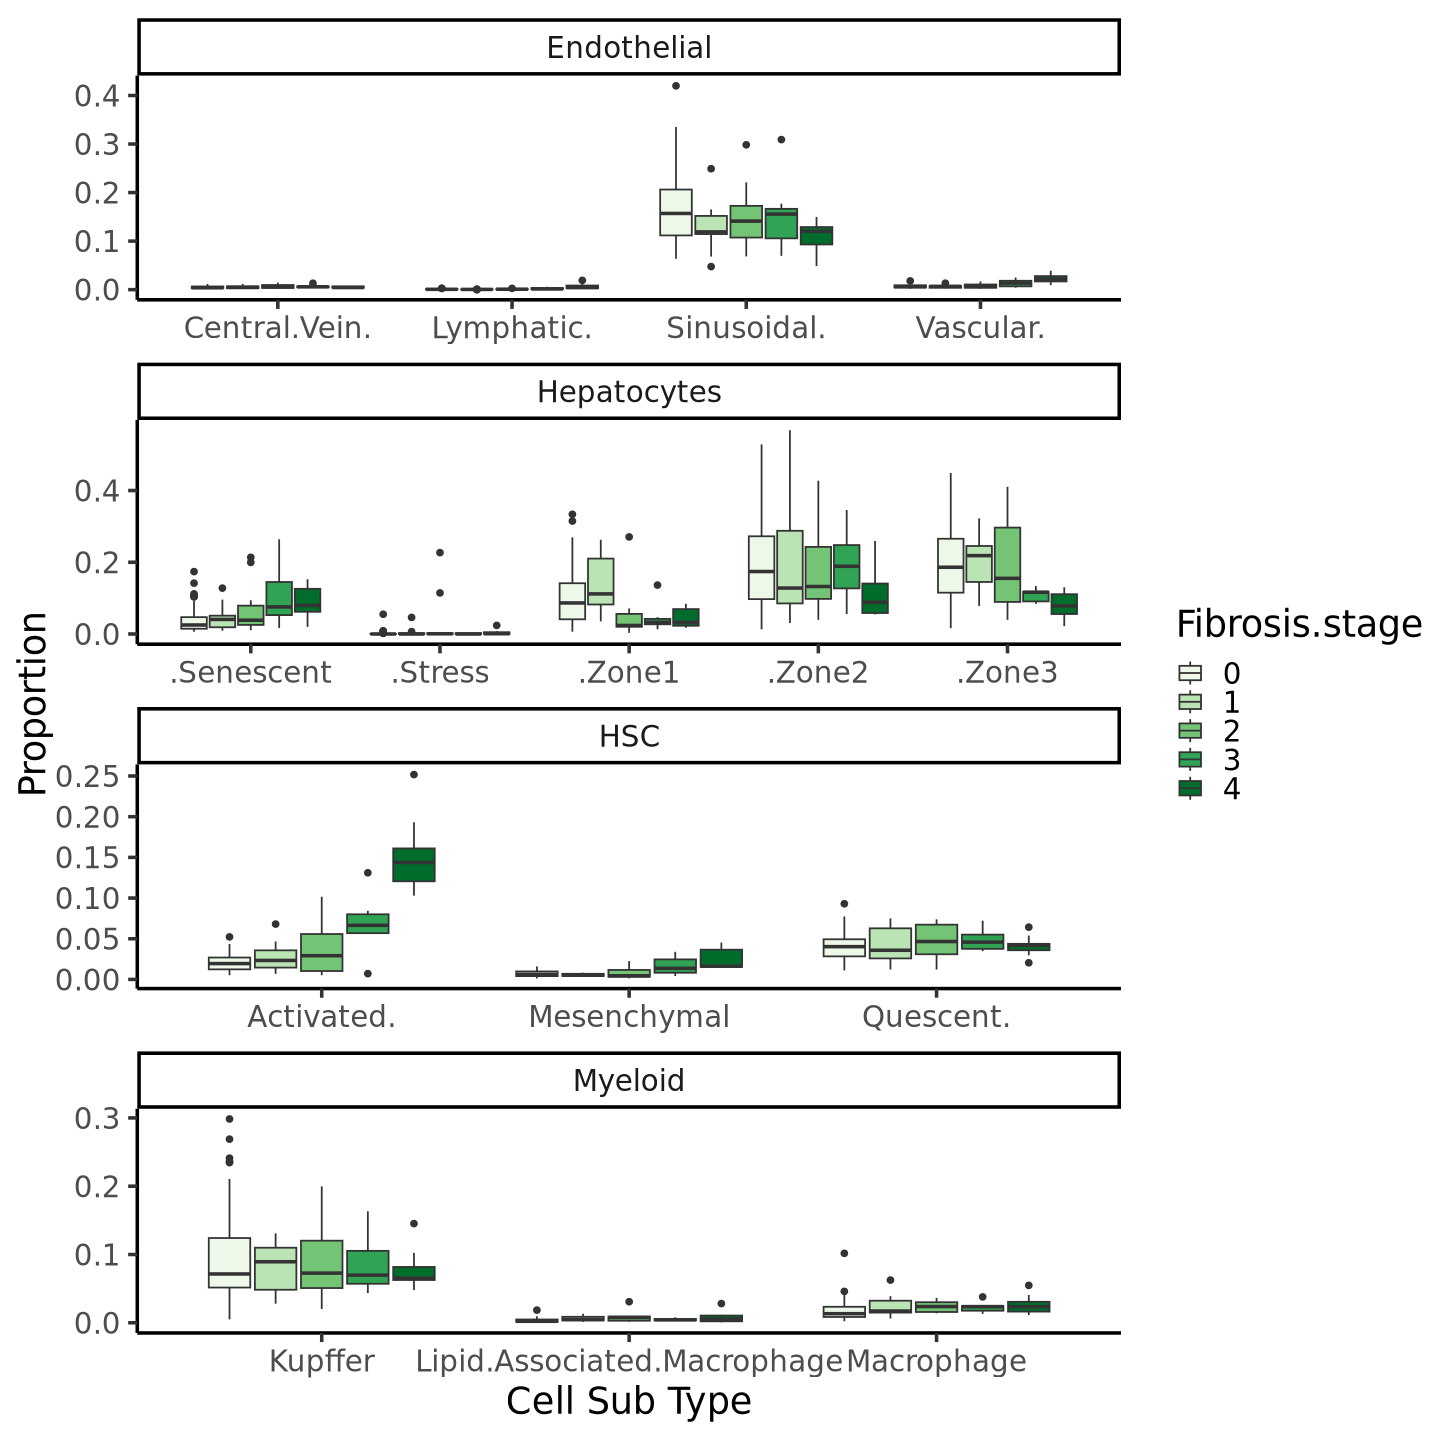

In [73]:
options(repr.plot.width=12, repr.plot.height=12)
p1 <- meta_df.sub %>%
    mutate(total_cells=Activated.HSC+B+Central.Vein.Endothelial+Cholangiocyte+Hepatocytes.Senescent+
           Hepatocytes.Stress+Hepatocytes.Zone1+Hepatocytes.Zone2+Hepatocytes.Zone3+Kupffer+
           Lipid.Associated.Macrophage+Lymphatic.Endothelial+Macrophage+Mast+Mesenchymal+
           NK+Plasma+Quescent.HSC+Schwann+Sinusoidal.Endothelial+T+Vascular.Endothelial) %>%
    select(Activated.HSC, B, Central.Vein.Endothelial, Cholangiocyte, Hepatocytes.Senescent, 
           Hepatocytes.Stress, Hepatocytes.Zone1, Hepatocytes.Zone2, Hepatocytes.Zone3, 
           Kupffer, Lipid.Associated.Macrophage, Lymphatic.Endothelial, Macrophage, Mast, 
           Mesenchymal, NK, Plasma, Quescent.HSC, Schwann, Sinusoidal.Endothelial, T, 
           Vascular.Endothelial, total_cells, donor, Fibrosis.stage) %>%
    mutate(across(c(-donor, -Fibrosis.stage), ~ . / total_cells)) %>%
    pivot_longer(c(Activated.HSC, B, Central.Vein.Endothelial, Cholangiocyte, Hepatocytes.Senescent, 
           Hepatocytes.Stress, Hepatocytes.Zone1, Hepatocytes.Zone2, Hepatocytes.Zone3, 
           Kupffer, Lipid.Associated.Macrophage, Lymphatic.Endothelial, Macrophage, Mast, 
           Mesenchymal, NK, Plasma, Quescent.HSC, Schwann, Sinusoidal.Endothelial, T, 
           Vascular.Endothelial, total_cells), 
                 names_to='Cell_Type',values_to='Proportion') %>%
    mutate(Fibrosis.stage=factor(Fibrosis.stage, levels=rev(4:0))) %>%
    filter(Cell_Type != 'total_cells') %>%
    group_by(Cell_Type) %>%
    left_join(lineage) %>%
    filter(Group != 'Other') %>%
    mutate(Cell_Type=str_remove(Cell_Type, Group)) %>%
    ggplot(aes(x=Cell_Type, y=Proportion, fill=Fibrosis.stage)) +
        geom_boxplot() +
        theme_classic(base_size=22) +
        scale_fill_brewer(palette = 'Greens', direction = 1) +
        labs(x='Cell Sub Type', fill='Fibrosis.stage') +
        facet_wrap(. ~ Group, scales='free', ncol=1)

p1

ggsave(plot = p1, filename = '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260511_WE_scCODA_Subtype_Fibrosis_Stage_R_Proportions.pdf', width=12, height=12)

options(repr.plot.width=8, repr.plot.height=8)

In [7]:
read.table('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage.results')

Warning message in read.table("/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage.results"):
“line 1 appears to contain embedded nulls”


ERROR: Error in make.names(col.names, unique = TRUE): invalid multibyte string at '<80><95>/'


In [7]:
scCODA.res <- read.table(text='CellType,FinalParameter,ExpectedSample,log2-foldchange
B,0.000000,106.017570,0.017173   
Cholangiocyte,0.250016,162.003988,0.377870   
Endothelial,0.000000,816.155445,0.017173   
Hepatocytes,-0.078106,2292.730855,-0.095510   
HSC,0.243639,432.786169,0.368670   
Mast,0.000000,32.124046,0.017173   
Myeloid,0.000000,542.183678,0.017173   
NK,0.000000,144.547017,0.017173   
Schwann,0.000000,40.149293,0.017173   
T,0.000000,177.790312,0.017173', sep=',', header=T)
scCODA.res

CellType,FinalParameter,ExpectedSample,log2.foldchange
<chr>,<dbl>,<dbl>,<dbl>
B,0.000000,106.01757,0.017173
Cholangiocyte,0.250016,162.00399,0.377870
Endothelial,0.000000,816.15544,0.017173
Hepatocytes,-0.078106,2292.73085,-0.095510
HSC,0.243639,432.78617,0.368670
Mast,0.000000,32.12405,0.017173
Myeloid,0.000000,542.18368,0.017173
NK,0.000000,144.54702,0.017173
Schwann,0.000000,40.14929,0.017173


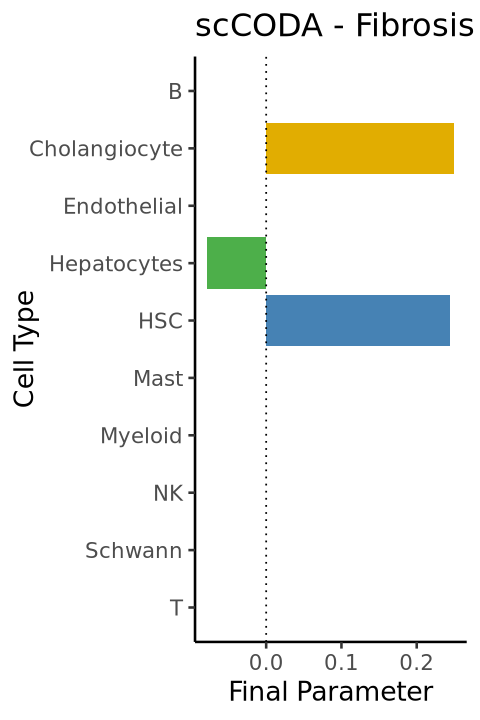

In [8]:
options(repr.plot.width=4, repr.plot.height=6)
p1 <- scCODA.res %>%
    ggplot(aes(x=FinalParameter, y=CellType, fill=CellType)) +
        geom_col() +
        scale_fill_manual(values = celltype_colors) +
        theme_classic(base_size=16) +
        theme(legend.position='none') +
        labs(y='Cell Type', x="Final Parameter") +
        ggtitle('scCODA - Fibrosis Stage') +
        geom_vline(xintercept = 0, linetype='dotted') +
        scale_y_discrete(limits = rev)

p1
options(repr.plot.width=8, repr.plot.height=8)

ggsave(p1, filename='/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260511_WE_scCODA_Fibsosis_Stage.png', width=4, height=6)
ggsave(p1, filename='/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260511_WE_scCODA_Fibsosis_Stage.pdf', width=4, height=6)

In [1]:
scCODA.res.subtypes <- read.table(text='CellType,FinalParameter,ExpectedSample,log2-foldchange
Activated.HSC,0.424845,179.830881,0.598469
B,0.000000,51.068685,-0.014454
Central.Vein.Endothelial,0.000000,64.985976,-0.014454
Cholangiocyte,0.306637,150.627214,0.427929
Hepatocytes.Senescent,0.224390,232.191197,0.309272
Hepatocytes.Stress,0.000000,26.132284,-0.014454
Hepatocytes.Zone1,-0.145002,340.416368,-0.223647
Hepatocytes.Zone2,0.000000,762.933978,-0.014454
Hepatocytes.Zone3,-0.106335,749.072993,-0.167863
Kupffer,0.000000,417.452806,-0.014454
Lipid.Associated.Macrophage,0.000000,51.376019,-0.014454
Lymphatic.Endothelial,0.000000,30.452604,-0.014454
Macrophage,0.000000,126.998020,-0.014454
Mast,0.000000,26.580331,-0.014454
Mesenchymal,0.194194,81.155380,0.265709
NK,0.000000,131.258872,-0.014454
Plasma,0.000000,66.697769,-0.014454
Quescent.HSC,0.000000,227.277445,-0.014454
Schwann,0.000000,34.749719,-0.014454
Sinusoidal.Endothelial,0.000000,744.097071,-0.014454
T,0.126593,180.506054,0.168181
Vascular.Endothelial,0.000000,70.963914,-0.014454', sep=',', header=T)
scCODA.res.subtypes

CellType,FinalParameter,ExpectedSample,log2.foldchange
<chr>,<dbl>,<dbl>,<dbl>
Activated.HSC,0.424845,179.83088,0.598469
B,0.000000,51.06869,-0.014454
Central.Vein.Endothelial,0.000000,64.98598,-0.014454
Cholangiocyte,0.306637,150.62721,0.427929
Hepatocytes.Senescent,0.224390,232.19120,0.309272
Hepatocytes.Stress,0.000000,26.13228,-0.014454
Hepatocytes.Zone1,-0.145002,340.41637,-0.223647
Hepatocytes.Zone2,0.000000,762.93398,-0.014454
Hepatocytes.Zone3,-0.106335,749.07299,-0.167863


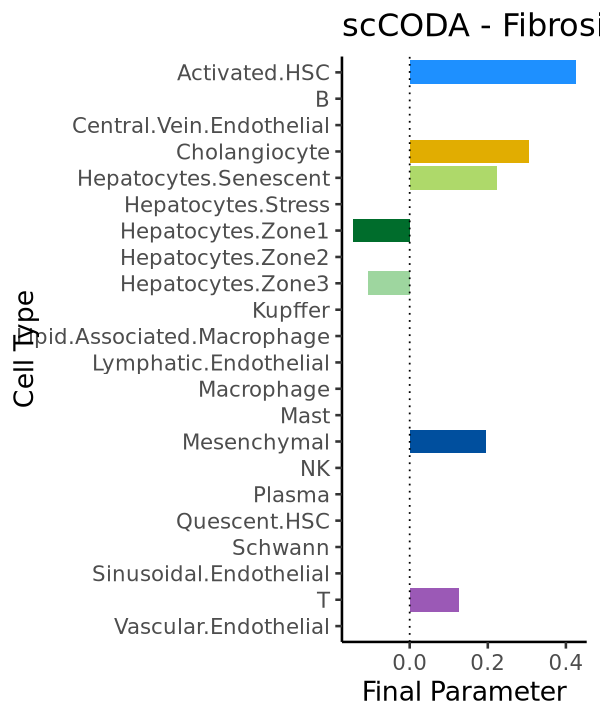

In [9]:
options(repr.plot.width=5, repr.plot.height=6)
p1 <- scCODA.res.subtypes %>%
    ggplot(aes(x=FinalParameter, y=CellType, fill=CellType)) +
        geom_col() +
        scale_fill_manual(values = cellsubtype_colors) +
        theme_classic(base_size=16) +
        theme(legend.position='none') +
        labs(y='Cell Type', x="Final Parameter") +
        ggtitle('scCODA - Fibrosis Stage') +
        geom_vline(xintercept = 0, linetype='dotted') +
        scale_y_discrete(limits = rev)

p1
options(repr.plot.width=8, repr.plot.height=8)

ggsave(p1, filename='/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260511_WE_scCODA_Fibsosis_Stage_subtypes.png', width=5, height=6)
ggsave(p1, filename='/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260511_WE_scCODA_Fibsosis_Stage_subtypes.pdf', width=5, height=6)

In [2]:
scCODA.res.hep <- read.table(text='CellType,FinalParameter,ExpectedSample,log2-foldchange
Hepatocytes.Senescent,114.865732,2.716657e+03,8.363547
Hepatocytes.Stress,0.000000,2.732836e-46,-157.352675
Hepatocytes.Zone1,0.000000,2.095421e-45,-157.352675
Hepatocytes.Zone2,0.000000,4.507554e-45,-157.352675
Hepatocytes.Zone3,0.000000,4.733925e-45,-157.352675', sep=',', header=T)
scCODA.res.hep

CellType,FinalParameter,ExpectedSample,log2.foldchange
<chr>,<dbl>,<dbl>,<dbl>
Hepatocytes.Senescent,114.8657,2.716657e+03,8.363547
Hepatocytes.Stress,0.0000,2.732836e-46,-157.352675
Hepatocytes.Zone1,0.0000,2.095421e-45,-157.352675
Hepatocytes.Zone2,0.0000,4.507554e-45,-157.352675
Hepatocytes.Zone3,0.0000,4.733925e-45,-157.352675


# Making a summary table

In [2]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(stringr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [1]:
res.dir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/'

In [11]:
data.frame(file=list.files(res.dir, pattern='csv')) %>%
    mutate(analysis.group=ifelse(str_detect(file, 'cell_subtype'), 'All Subtypes',
                          ifelse(str_detect(file, 'Hep'), "Hepatocyte Subtypes", 'Celltypes')))

file,analysis.group
<chr>,<chr>
260330_scCODA_condition_by_fib_pairwise.sccoda_effects.csv,Celltypes
260330_scCODA_condition_cell_subtype_by_fib_pairwise.sccoda_effects.csv,All Subtypes
260330_scCODA_condition_cell_subtype_distinct.sccoda_effects.csv,All Subtypes
260330_scCODA_condition_distinct.sccoda_effects.csv,Celltypes
260330_scCODA_condition_Hep_subtype_by_fib_pairwise.sccoda_effects.csv,Hepatocyte Subtypes
260330_scCODA_condition_Hep_subtype_distinct.sccoda_effects.csv,Hepatocyte Subtypes
260330_scCODA_Fibrosis_stage_cell_subtype.sccoda_effects.csv,All Subtypes
260330_scCODA_Fibrosis_stage_Hep_subtype.sccoda_effects.csv,Hepatocyte Subtypes
260330_scCODA_Fibrosis_stage.sccoda_effects.csv,Celltypes


In [37]:
full.sccoda <- bind_rows(read.table(paste0(res.dir, '260330_scCODA_Fibrosis_stage.sccoda_effects.csv'), sep='\t', header=T) %>%
    mutate(Covariate=str_remove(str_replace(
        str_remove(Covariate, 'C\\(condition_cat, Treatment\\(Control\\)\\)\\['), 
        '\\]', '_vs_Control'), 'T\\.')) %>%
    mutate(Annotation='Celltypes'),
    read.table(paste0(res.dir, '260330_scCODA_Fibrosis_stage_cell_subtype.sccoda_effects.csv'), sep='\t', header=T) %>%
    mutate(Covariate=str_remove(str_replace(
        str_remove(Covariate, 'C\\(condition_cat, Treatment\\(Control\\)\\)\\['), 
        '\\]', '_vs_Control'), 'T\\.')) %>%
    mutate(Annotation='Cell Subtypes')) %>%
bind_rows(read.table(paste0(res.dir, '260330_scCODA_Fibrosis_stage_Hep_subtype.sccoda_effects.csv'), sep='\t', header=T) %>%
    mutate(Covariate=str_remove(str_replace(
        str_remove(Covariate, 'C\\(condition_cat, Treatment\\(Control\\)\\)\\['), 
        '\\]', '_vs_Control'), 'T\\.')) %>%
    mutate(Annotation='Hepatocyte Subtypes')) %>%
bind_rows(read.table(paste0(res.dir, '260330_scCODA_condition_distinct.sccoda_effects.csv'), sep='\t', header=T) %>%
    mutate(Covariate=str_remove(str_replace(
        str_remove(Covariate, 'C\\(condition_cat, Treatment\\(Control\\)\\)\\['), 
        '\\]', '_vs_Control'), 'T\\.')) %>%
    mutate(Annotation='Celltypes')) %>%
bind_rows(read.table(paste0(res.dir, '260330_scCODA_condition_cell_subtype_distinct.sccoda_effects.csv'), sep='\t', header=T) %>%
    mutate(Covariate=str_remove(str_replace(
        str_remove(Covariate, 'C\\(condition_cat, Treatment\\(Control\\)\\)\\['), 
        '\\]', '_vs_Control'), 'T\\.')) %>%
    mutate(Annotation='Cell Subtypes')) %>%
bind_rows(read.table(paste0(res.dir, '260330_scCODA_condition_Hep_subtype_distinct.sccoda_effects.csv'), sep='\t', header=T) %>%
    mutate(Covariate=str_remove(str_replace(
        str_remove(Covariate, 'C\\(condition_cat, Treatment\\(Control\\)\\)\\['), 
        '\\]', '_vs_Control'), 'T\\.')) %>%
    mutate(Annotation='Hepatocyte Subtypes')) %>%
bind_rows(read.table(paste0(res.dir, '260330_scCODA_condition_by_fib_pairwise.sccoda_effects.csv'), sep='\t', header=T) %>%
    mutate(Covariate=str_remove(str_replace(
        str_remove(Covariate, 'C\\(condition_cat, Treatment\\(Control\\)\\)\\['), 
        '\\]', '_vs_Control'), 'T\\.')) %>%
    mutate(Annotation='Celltypes') %>%
    filter(Covariate != 'MASL_vs_Control')) %>%
bind_rows(read.table(paste0(res.dir, '260330_scCODA_condition_cell_subtype_by_fib_pairwise.sccoda_effects.csv'), sep='\t', header=T) %>%
    mutate(Covariate=str_remove(str_replace(
        str_remove(Covariate, 'C\\(condition_cat, Treatment\\(Control\\)\\)\\['), 
        '\\]', '_vs_Control'), 'T\\.')) %>%
    mutate(Annotation='Cell Subtypes') %>%
    filter(Covariate != 'MASL_vs_Control')) %>%
bind_rows(read.table(paste0(res.dir, '260330_scCODA_condition_Hep_subtype_by_fib_pairwise.sccoda_effects.csv'), sep='\t', header=T) %>%
    mutate(Covariate=str_remove(str_replace(
        str_remove(Covariate, 'C\\(condition_cat, Treatment\\(Control\\)\\)\\['), 
        '\\]', '_vs_Control'), 'T\\.')) %>%
    mutate(Annotation='Hepatocyte Subtypes') %>%
    filter(Covariate != 'MASL_vs_Control'))

dim(full.sccoda)
head(full.sccoda)

[1] 222  10

,Covariate,Cell.Type,Final.Parameter,HDI.3.,HDI.97.,SD,Inclusion.probability,Expected.Sample,log2.fold.change,Annotation
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,Fibrosis_stage,B,0.00000000,0.000,0.000,0.000,0.0000000,105.95346,0.01207398,Celltypes
2,Fibrosis_stage,Cholangiocyte,0.25292041,0.115,0.363,0.066,1.0000000,162.86479,0.37696100,Celltypes
3,Fibrosis_stage,Endothelial,0.00000000,-0.099,0.066,0.025,0.3138667,814.84663,0.01207398,Celltypes
4,Fibrosis_stage,Hepatocytes,-0.07346145,-0.143,-0.022,0.042,0.7410000,2290.52989,-0.09390850,Celltypes
5,Fibrosis_stage,HSC,0.25623085,0.163,0.350,0.049,1.0000000,434.94986,0.38173695,Celltypes
6,Fibrosis_stage,Mast,0.00000000,-0.164,0.093,0.043,0.3464667,32.29783,0.01207398,Celltypes


In [38]:
full.sccoda

Covariate,Cell.Type,Final.Parameter,HDI.3.,HDI.97.,SD,Inclusion.probability,Expected.Sample,log2.fold.change,Annotation
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Fibrosis_stage,B,0.00000000,0.000,0.000,0.000,0.0000000,105.95346,0.01207398,Celltypes
Fibrosis_stage,Cholangiocyte,0.25292041,0.115,0.363,0.066,1.0000000,162.86479,0.37696100,Celltypes
Fibrosis_stage,Endothelial,0.00000000,-0.099,0.066,0.025,0.3138667,814.84663,0.01207398,Celltypes
Fibrosis_stage,Hepatocytes,-0.07346145,-0.143,-0.022,0.042,0.7410000,2290.52989,-0.09390850,Celltypes
Fibrosis_stage,HSC,0.25623085,0.163,0.350,0.049,1.0000000,434.94986,0.38173695,Celltypes
Fibrosis_stage,Mast,0.00000000,-0.164,0.093,0.043,0.3464667,32.29783,0.01207398,Celltypes
Fibrosis_stage,Myeloid,0.00000000,-0.029,0.124,0.034,0.3658667,542.94060,0.01207398,Celltypes
Fibrosis_stage,NK,0.00000000,-0.141,0.083,0.037,0.2888000,145.18371,0.01207398,Celltypes
Fibrosis_stage,Schwann,0.00000000,-0.088,0.145,0.040,0.3480667,40.12501,0.01207398,Celltypes


In [39]:
select(full.sccoda, Covariate, Cell.Type) %>% table()
select(full.sccoda, Covariate, Annotation) %>% table()

                     Cell.Type
Covariate             Activated.HSC B Central.Vein.Endothelial Cholangiocyte
  Fibrosis_stage                  1 2                        1             2
  High_Fib_vs_Control             1 2                        1             2
  Low_Fib_vs_Control              1 2                        1             2
  MASH_vs_Control                 1 2                        1             2
  MASL_vs_Control                 1 2                        1             2
  MetALD_vs_Control               1 2                        1             2
                     Cell.Type
Covariate             Endothelial Hepatocytes Hepatocytes.Senescent
  Fibrosis_stage                1           1                     2
  High_Fib_vs_Control           1           1                     2
  Low_Fib_vs_Control            1           1                     2
  MASH_vs_Control               1           1                     2
  MASL_vs_Control               1           1              

                     Annotation
Covariate             Cell Subtypes Celltypes Hepatocyte Subtypes
  Fibrosis_stage                 22        10                   5
  High_Fib_vs_Control            22        10                   5
  Low_Fib_vs_Control             22        10                   5
  MASH_vs_Control                22        10                   5
  MASL_vs_Control                22        10                   5
  MetALD_vs_Control              22        10                   5

In [54]:
filter(full.sccoda, Final.Parameter != 0) %>%
    arrange(Cell.Type) %>%
    filter(Annotation != 'Hepatocyte Subtypes') %>%
    select(Contrast=Covariate, everything())  %>%
    mutate(Contrast=ifelse(Contrast=='High_Fib_vs_Control','Fib+MASH_vs_Control', Contrast)) %>%
    mutate(Contrast=ifelse(Contrast=='Low_Fib_vs_Control','Fib-MASH_vs_Control', Contrast)) %>%
    mutate(Cell.Type=ifelse(Cell.Type=='Hepatocytes.Senescent', 'Hepatocytes.Inflammatory', Cell.Type))

Contrast,Cell.Type,Final.Parameter,HDI.3.,HDI.97.,SD,Inclusion.probability,Expected.Sample,log2.fold.change,Annotation
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Fibrosis_stage,Activated.HSC,0.42484536,0.328,0.502,0.046,1.0000000,179.30474,0.59424143,Cell Subtypes
MASH_vs_Control,Activated.HSC,0.55353719,0.211,0.898,0.187,0.9940000,267.10466,0.76365705,Cell Subtypes
Fib+MASH_vs_Control,Activated.HSC,1.35020275,1.070,1.633,0.149,1.0000000,479.59414,1.70304232,Cell Subtypes
Fibrosis_stage,Cholangiocyte,0.25292041,0.115,0.363,0.066,1.0000000,162.86479,0.37696100,Celltypes
Fibrosis_stage,Cholangiocyte,0.30663650,0.210,0.395,0.052,1.0000000,150.18651,0.42370209,Cell Subtypes
Fib+MASH_vs_Control,Cholangiocyte,0.83126338,0.422,1.224,0.215,1.0000000,320.79102,1.21009280,Celltypes
Fib+MASH_vs_Control,Cholangiocyte,1.02716736,0.694,1.340,0.176,1.0000000,309.48351,1.23700076,Cell Subtypes
Fibrosis_stage,HSC,0.25623085,0.163,0.350,0.049,1.0000000,434.94986,0.38173695,Celltypes
MASH_vs_Control,HSC,0.37619822,0.089,0.694,0.186,0.9136000,549.60336,0.48938848,Celltypes


In [56]:
full.sccoda %>%
    arrange(Covariate, desc(abs(Final.Parameter))) %>%
    filter(Annotation != 'Hepatocyte Subtypes') %>%
    select(Contrast=Covariate, everything())  %>%
    mutate(Contrast=ifelse(Contrast=='High_Fib_vs_Control','Fib+MASH_vs_Control', Contrast)) %>%
    mutate(Contrast=ifelse(Contrast=='Low_Fib_vs_Control','Fib-MASH_vs_Control', Contrast)) %>%
    mutate(Cell.Type=ifelse(Cell.Type=='Hepatocytes.Senescent', 'Hepatocytes.Inflammatory', Cell.Type)) %>%
    write.table(paste0(res.dir, '260628_WE_Combined_scCODA_results.tsv'), sep='\t', col.names=T, row.names=F, quote=F)

In [55]:
full.sccoda %>%
    arrange(Covariate, desc(abs(Final.Parameter))) %>%
    filter(Annotation != 'Hepatocyte Subtypes') %>%
    select(Contrast=Covariate, everything())  %>%
    mutate(Contrast=ifelse(Contrast=='High_Fib_vs_Control','Fib+MASH_vs_Control', Contrast)) %>%
    mutate(Contrast=ifelse(Contrast=='Low_Fib_vs_Control','Fib-MASH_vs_Control', Contrast)) %>% 
    mutate(Cell.Type=ifelse(Cell.Type=='Hepatocytes.Senescent', 'Hepatocytes.Inflammatory', Cell.Type)) %>%
    select(Contrast, Cell.Type) %>% table()

                     Cell.Type
Contrast              Activated.HSC B Central.Vein.Endothelial Cholangiocyte
  Fib-MASH_vs_Control             1 2                        1             2
  Fib+MASH_vs_Control             1 2                        1             2
  Fibrosis_stage                  1 2                        1             2
  MASH_vs_Control                 1 2                        1             2
  MASL_vs_Control                 1 2                        1             2
  MetALD_vs_Control               1 2                        1             2
                     Cell.Type
Contrast              Endothelial Hepatocytes Hepatocytes.Inflammatory
  Fib-MASH_vs_Control           1           1                        1
  Fib+MASH_vs_Control           1           1                        1
  Fibrosis_stage                1           1                        1
  MASH_vs_Control               1           1                        1
  MASL_vs_Control               1           